# Stochastic Analysis of NANOGrav 15-year dataset

This notebook reproduces (some) results from the NANOGrav 15-year stochastic analysis.

### Requirements

- This notebook should be executed on a (NVIDIA) GPU with CUDA-enabled JAX.

- The analysis requires the packages imported in the following cell, and other common packages.

- By default, single precision (`float32`) is used. If desired, use double precision by modifying the `__init__.py` file, but this slows down the analysis.

In [1]:
# to load/save objects
import json
import pickle
from la_forge import core
from enterprise_extensions.load_feathers import load_feathers_from_folder

# for plotting
import numpy as np
import matplotlib.pyplot as plt
import corner
from iris import Iris

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

# prometheus objects
from prometheus import data
from prometheus.spectral_models import IndependentSpectralModel, CommonSpectralModel
from prometheus import spectra
from prometheus.pta_model import PTAModel
from prometheus import utilities as utils

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [2]:
# check that we are running on a GPU
# this should print something like "CudaDevice(id=...)"
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


## Load Data

**Prometheus** stores PTA data in a custom `prometheus.data.Data` object. This object may be constructed from a list of `enterprise.Pulsar.PintPulsar` (or `FeatherPulsar`) objects and a white noise dictionary.

The `Data` object needs only be constructed once per dataset, after which it can be stored and used repeatedly under different models. The only exception is when we wish to change the number of frequency bins in the pulsar noise or deterministic signal model.

First we'll load the pulsar objects and white noise dictionary (obtained from the [NANOGrav 15-year stochastic analysis GitHub repository](https://github.com/nanograv/15yr_stochastic_analysis/tree/main/tutorials/data)).

In [3]:
# load feather pulsar objects
psrs = load_feathers_from_folder('../data/NG15/feathers')

# load white noise dictionary
with open('../data/NG15/15yr_wn_dict.json', 'r') as fp:
    wn_dict = json.load(fp)

# optional: load dictionary of pulsar distances
# used in CW analysis
with open('../data/NG15/pulsar_distances_15yr.pkl', 'rb') as fp:
    psr_dists_dict = pickle.load(fp)

FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J1312+0051.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0613-0200.feather.
FeatherPulsar.read_feather: cannot find fitpars in feather file ../data/NG15/feathers/v1p1_de440_pint_bipm2019-J0610-2100.feather.
FeatherPulsar.read_feather: cannot find setpars in feather file ../data/NG15/feathers

In [4]:
# now we can construct the prometheus.data.Data object
NG15_data = data.Data(name='NG15',
                      psrs=psrs,
                      wn_dict=wn_dict,
                      nfreqs=30,
                      psr_dists_dict=psr_dists_dict)
print(type(NG15_data))

building pulsar models:   0%|          | 0/67 [00:00<?, ?it/s, running J1312+0051]

building pulsar models: 100%|██████████| 67/67 [02:18<00:00,  2.07s/it, running J0437-4715]


<class 'prometheus.data.Data'>


In [5]:
# save the data object for future analyses
NG15_data.save_data(filepath='../data/NG15/data.pkl')

# or load a previously constructed data object
# with open('../data/NG15/data.pkl', 'rb') as fp:
#     NG15_data = pickle.load(fp)

Saved data object to ../data/NG15/data.pkl.


In [6]:
# the data object contains useful attributes
print(f'number of pulsars in array = {NG15_data.npsrs}')
print(f'total observation span [s] = {NG15_data.Tspan}')
print(f'first few pulsar names in array = {NG15_data.psr_names[:3]}')
print(f'distance to first pulsar [kpc] = {NG15_data.psr_dists_measured[0]}')

number of pulsars in array = 67
total observation span [s] = 505861299.1401644
first few pulsar names in array = ['J1312+0051', 'J0613-0200', 'J0610-2100']
distance to first pulsar [kpc] = 0.8428000211715698


## Construct Spectral Models

**Prometheus** requires two spectral models to perform parameter estimation:

1) `prometheus.spectral_models.IndependentSpectralModel`: 
- This corresponds to the intrinsic pulsar noise model.
- It assumes the same spectral model (e.g. power law) is applied independently to every pulsar in the array.

2) `prometheus.spectral_models.CommonSpectralModel`:
- This corresponds to a gravitational wave background, or some common stochastic process.
- A common spectrum is applied to all pulsars under some correlation matrix.
- HD and CURN correlations are supported, or you can plug in your own pulsar correlation matrix.

Each spectral model corresponds to a Gaussian process for the Fourier coefficients which represent the stochastic component of the timing residuals. The spectral models require a callable input: `get_phi_diag_func`. This function should take an array of spectral parameters and an array frequencies as input, and outputs the diagonal elements of the covariance matrix used in the prior on the Fourier coefficients. Common `get_phi_diag_func` are available in `spectra.py`, or you can build your own custom spectrum.

Advanced users need not adhere to the two-spectral-model-requirement above. Instead they can create their own custom `prometheus.spectral_models.SpectralModel`. This takes a bit more work - see the `advanced_modeling` example notebooks.

In [7]:
# we'll model the pulsar noise with a power law
# the IndependentSpectralModel automatically applies this model to
# every pulsar in the array independently
psr_model = IndependentSpectralModel(name='psr_params',
                                     get_phi_diag_func=spectra.power_law,
                                     parameter_bounds=[[-20., -10.], # log10_amp bounds
                                                       [0., 7.]],    # spectral index bounds
                                     data=NG15_data)

# model the GWB with a power law and HD correlations
# also specify the number of frequency bins used in the GWB model
gwb_model = CommonSpectralModel(name='gwb_params',
                                get_phi_diag_func=spectra.power_law,
                                parameter_bounds=[[-20., -10.], # log10_amp bounds
                                                    [0., 7.]],  # spectral index bounds
                                correlation_matrix='HD',
                                data=NG15_data,
                                nfreqs=14)

## Build a PTA Model

Now we put everything together in a `prometheus.pta_model.PTAModel` object.

In [8]:
# plug pulsar noise and GWB model into the PTA model
pta_model = PTAModel(psr_model=psr_model,
                     gwb_model=gwb_model)
print(type(pta_model))

<class 'prometheus.pta_model.PTAModel'>


## Sample the posterior!

The `PTAModel` builds a NumPyro probabilistic sampling model. We'll use NumPyro's No U-Turn Sampler (NUTS), an extension of Hamiltonian Monte Carlo (HMC) to sample the posterior. For an introduction to HMC sampling, see e.g. [this paper](https://arxiv.org/abs/1701.02434).

On a decent GPU, the cell below should take ~15 minutes to sample. Because we use HMC, the 5000 samples are _nearly_ independent!

__WARNING__: On occasion, the NUTS sampler will warm-up in a non-representative region of parameter space, which causes poor sampling. This is an unfortunate feature of sampling in a 5000-dimensional parameter space. You can identify this failure by examining the step-size after running for 100 HMC steps or so. If the step-size falls below $\sim 10^{-5}$, terminate the run and try again - this time with a different random seed. You should find an average step-size of $\sim 10^{-2}$ for this dataset and model.

In [9]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# seed to start sampling
# (see "WARNING" above: change if necessary)
seed = 150914

# sample!
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

sample: 100%|██████████| 6000/6000 [15:34<00:00,  6.42it/s, 127 steps of size 3.63e-02. acc. prob=0.93] 


In [10]:
# uncomment to examine sampling diagnostics
# (this is a long output because we sample 
# ALL the Fourier coefficients)

# mcmc.print_summary()

In [11]:
# save samples to feather file
utils.save_chain(samples_dict=samples,
                 filepath='chains/NG15_HD_PL_Nf14.feather',
                 save_coeff_samples=False)

# we can also load samples
# samples = utils.load_chain('chains/NG15_HD_PL_Nf14.feather')

Saved chain samples to chains/NG15_HD_PL_Nf14.feather.


## Post-processing

Let's make some plots using Prometheus' companion plotting package `Iris` to help. Alternatively, we can use the raw `samples` from above which is a Python dictionary.

In [12]:
plotter = Iris(pta_model, samples)

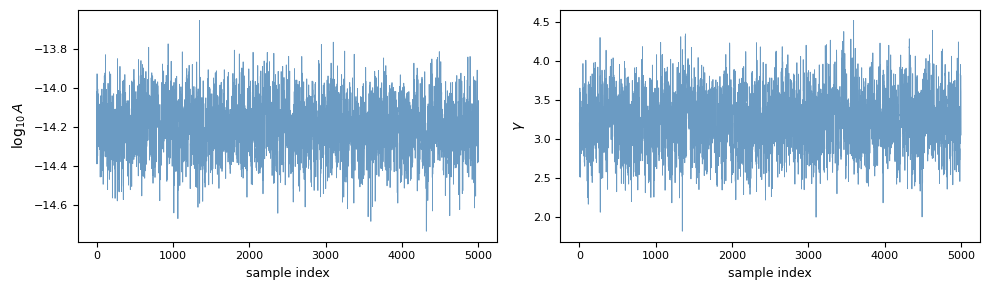

In [13]:
fig = plotter.trace(plotter.gwb_model_params())

In [14]:
# we're going to compare our results with Enterprise,
# so we'll load a pre-sampled Enterprise chain here
enterprise_core = core.Core(corepath='chains/hd_14f_pl_vg.core')

# Enterprise GWB samples
ent_gwb_samples = np.array([enterprise_core.get_param('gw__log10_A'),
                                   enterprise_core.get_param('gw__gamma')]).T

# Enterprise pulsar noise samples
ent_psr_noise_samples = np.transpose(np.array([[enterprise_core.get_param(f'{psr_name}_red_noise_log10_A'),
                                                enterprise_core.get_param(f'{psr_name}_red_noise_gamma')]
                                                for psr_name in NG15_data.psr_names]), axes=(2, 0, 1))

# store Enterprise samples in dictionary (same format as Prometheus) for comparison
enterprise_samples = {gwb_model.name : ent_gwb_samples,
                      psr_model.name : ent_psr_noise_samples}

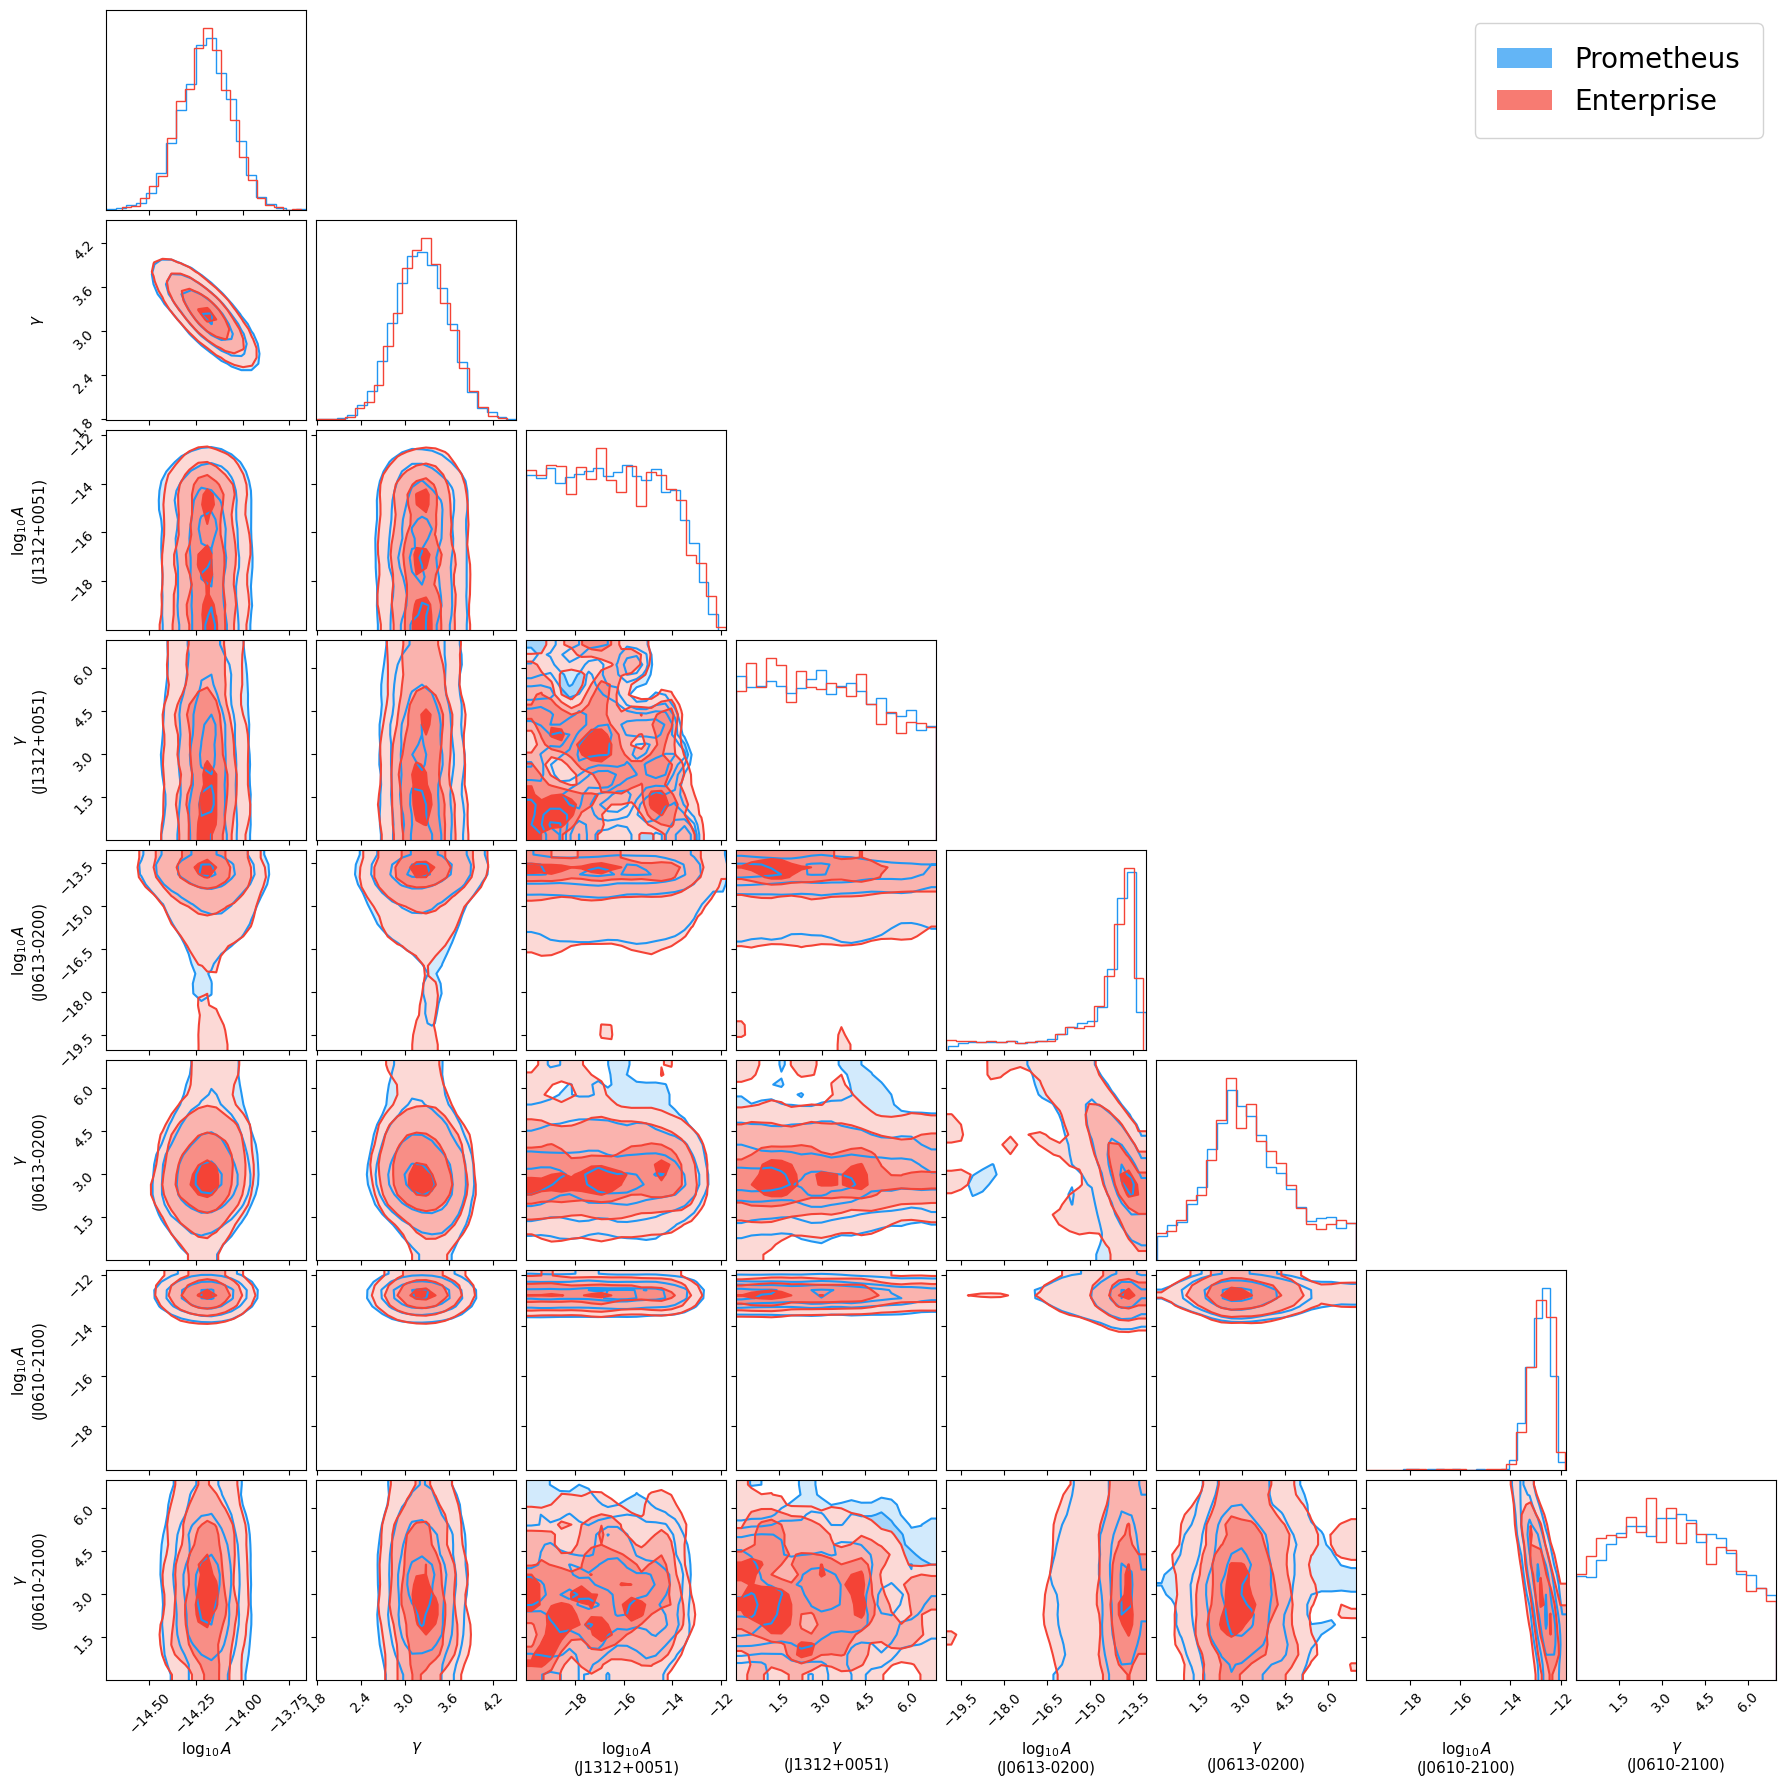

In [15]:
# plot GWB recovery and noise recovery in first few pulsars
fig = plotter.corner(params= plotter.gwb_model_params() + \
                     plotter.psr_model_params(psr_indices=np.r_[:3]),
               extra_samples=[enterprise_samples],
               labels=['Prometheus', 'Enterprise'],
               legend_fontsize=20,
               bins=20)